In [92]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

In [77]:
PATH = 'datasets/ISIC_2020_corrected'
os.listdir(PATH)

['subset.csv',
 'test_split.csv',
 'train',
 'train.csv',
 'train_resized',
 'train_sd_split.csv',
 'train_split.csv',
 'val_split.csv']

In [79]:
train = pd.read_csv(f'{PATH}/subset.csv')
#train = pd.read_csv(f'{PATH}/train_sd_split.csv')

train.shape

(2319, 9)

In [80]:
train.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_8130007,IP_5229014,IL_1982348,male,55.0,upper extremity,unknown,benign,0
1,ISIC_4820993,IP_3713422,IL_2860029,male,50.0,torso,unknown,benign,0
2,ISIC_6859051,IP_9927968,IL_7824946,male,35.0,lower extremity,unknown,benign,0
3,ISIC_3216482,IP_4204657,IL_0820225,female,40.0,lower extremity,unknown,benign,0
4,ISIC_7381220,IP_3434100,IL_4512578,female,60.0,torso,unknown,benign,0


In [81]:
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label
    
def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

def createModel():
    IMAGE_SIZE = (256, 256, 3)

    encoder = ResNet50V2(
        include_top=False,
        input_shape=IMAGE_SIZE,
        weights='imagenet'
    )
    encoder.trainable = False

    inputs = keras.Input(shape=IMAGE_SIZE)
    x = keras.layers.Rescaling(1./255)(inputs)
    x = encoder(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.AUC(name="auc")]
    )
    
    return model

def trainModel(model, train_ds, val_ds, cp_filepath):
    
    cb = tf.keras.callbacks.ModelCheckpoint(
        filepath = cp_filepath,
        monitor="val_auc",
        verbose=0,
        save_best_only=True,
        save_weights_only=True,
        mode="max"
    )
    
    history = model.fit(train_ds,
                epochs=10,
                validation_data=val_ds,
                validation_steps=10,
                callbacks=[cb]
               )
    return model, history


In [82]:
#Cross validation
FOLDS = 3
skf = StratifiedKFold(n_splits=FOLDS, random_state=42, shuffle=True)
auc_list = []
history_list = []
cp_filepath = 'models/checkpoints/baseline2_cv'

for f, (train_index, val_index) in enumerate(skf.split(X=np.zeros(len(train)), y=train['target'])):
    print(f+1)
    print(train_index.shape, val_index.shape)
    
    train_fold = train.iloc[train_index]
    val_fold = train.iloc[train_index]
    
    train_ds = load_ds(train_fold)
    val_ds = load_ds(val_fold)
    
    model = createModel()
    model, history = trainModel(model, train_ds, val_ds, cp_filepath)
    history_list.append(history)
    
    model.load_weights(cp_filepath)
    model.save(f'models/model_fold_cv{f+1}.h5')
    
    _, auc = model.evaluate(val_ds)
    auc_list.append(auc)

1
(1546,) (773,)
Epoch 1/10
25/25 [==============================] - 35s 1s/step - loss: 0.2129 - auc: 0.4187 - val_loss: 0.1012 - val_auc: 0.2852
Epoch 2/10
25/25 [==============================] - 23s 950ms/step - loss: 0.1136 - auc: 0.3783 - val_loss: 0.0959 - val_auc: 0.4280
Epoch 3/10
25/25 [==============================] - 6s 263ms/step - loss: 0.1006 - auc: 0.4450 - val_loss: 0.1389 - val_auc: 0.5795
Epoch 4/10
25/25 [==============================] - 14s 580ms/step - loss: 0.0914 - auc: 0.5846 - val_loss: 0.0770 - val_auc: 0.8051
Epoch 5/10
25/25 [==============================] - 12s 492ms/step - loss: 0.0870 - auc: 0.6825 - val_loss: 0.1005 - val_auc: 0.6797
Epoch 6/10
25/25 [==============================] - 7s 277ms/step - loss: 0.0831 - auc: 0.7540 - val_loss: 0.0680 - val_auc: 0.8072
Epoch 7/10
25/25 [==============================] - 5s 183ms/step - loss: 0.0786 - auc: 0.7815 - val_loss: 0.0767 - val_auc: 0.7776
Epoch 8/10
25/25 [==============================] - 5s 192

In [83]:
auc_list

[0.9052912592887878, 0.788347601890564, 0.9242069125175476]

In [84]:
np.mean(auc_list), np.std(auc_list)

(0.8726152578989664, 0.060084545273753016)

In [85]:
test = pd.read_csv(f'{PATH}/test_split.csv')
test_ds = load_ds(test)
for i in range(FOLDS):
    model = load_model(f"models/model_fold_cv{i+1}.h5")
    results = model.evaluate(test_ds)
    print(results)

78/78 [==============================] - 21s 252ms/step - loss: 0.0825 - auc: 0.7597
[0.08251339942216873, 0.7596966624259949]
78/78 [==============================] - 18s 228ms/step - loss: 0.0861 - auc: 0.6934
[0.08607413619756699, 0.6933646202087402]
78/78 [==============================] - 15s 190ms/step - loss: 0.0809 - auc: 0.7804
[0.0809478759765625, 0.7803590297698975]


In [86]:
weights = []
for i in range(FOLDS):
    model = load_model(f"models/model_fold_cv{i+1}.h5")
    weights.append(model.get_weights())

In [87]:
new_weights = list()
for weights_list_tuple in zip(*weights): 
    new_weights.append(
        np.array([np.array(w).mean(axis=0) for w in zip(*weights_list_tuple)])
    )

In [88]:
model.set_weights(new_weights)

In [89]:
model.evaluate(test_ds)


78/78 [==============================] - 22s 272ms/step - loss: 0.0805 - auc: 0.7799


[0.0804658830165863, 0.7798786759376526]

In [90]:
history.history

{'loss': [0.20785842835903168,
  0.11250327527523041,
  0.0966910868883133,
  0.08447962254285812,
  0.0778317078948021,
  0.07122357934713364,
  0.06762334704399109,
  0.06368692964315414,
  0.061137374490499496,
  0.05788475275039673],
 'auc': [0.4391534626483917,
  0.4208787679672241,
  0.5191768407821655,
  0.6648136377334595,
  0.746763288974762,
  0.8368565440177917,
  0.8544850945472717,
  0.8912296295166016,
  0.9010313749313354,
  0.9234023690223694],
 'val_loss': [0.15207195281982422,
  0.13552629947662354,
  0.07371076196432114,
  0.08388174325227737,
  0.05142319202423096,
  0.06392063200473785,
  0.07066787034273148,
  0.08450114727020264,
  0.06694933772087097,
  0.0660410076379776],
 'val_auc': [0.40346869826316833,
  0.4711466431617737,
  0.5291732549667358,
  0.7859771251678467,
  0.8617693781852722,
  0.8841595649719238,
  0.8847994208335876,
  0.8765023946762085,
  0.9331355690956116,
  0.9272022843360901]}

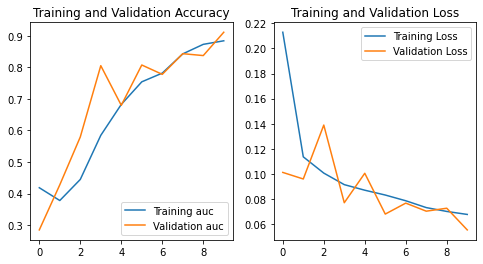

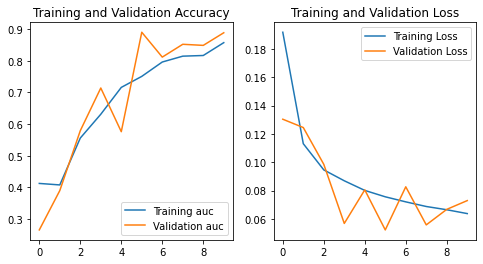

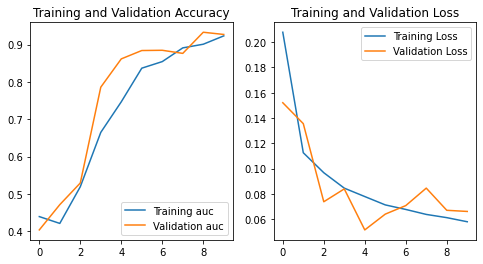

In [117]:
for i in range(3):
    h = history_list[i]
    auc = h.history['auc']
    val_auc = h.history['val_auc']

    loss = h.history['loss']
    val_loss = h.history['val_loss']

    epochs_range = range(10)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, auc, label='Training auc')
    plt.plot(epochs_range, val_auc, label='Validation auc')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

In [74]:
model.save(f'models/model_cv.h5')